# Regression Model Selection

## Importing the basic libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Load Dataset from Local Directory

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


## Importing the dataset

**AT: Ambient Temperature (in °C)  |  
V: Exhaust Vacuum (in cm Hg)  |  
AP: Ambient Pressure (in millibar)  |  
RH: Relative Humidity (in %)  |  
PE: Net Hourly Electrical Energy Output (in MW)**

In [3]:
dataset = pd.read_csv('dataset.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
ysvm = y.reshape(len(y),1)

## Splitting the dataset into the Training set and Test set

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Importing Machine Learning Algorithms

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

## Initializing different Regression algorithms

In [6]:
from sklearn.preprocessing import StandardScaler

modelLR  = LinearRegression()

poly_reg = PolynomialFeatures(degree = 4)
X_poly   = poly_reg.fit_transform(X_train)
modelPLR = LinearRegression()

modelRFR = RandomForestRegressor(n_estimators = 200, random_state = 0)
modelDTR = DecisionTreeRegressor(random_state = 0)

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(ysvm)

modelSVR = SVR(kernel='rbf')



### Training Regression algorithm

In [7]:
modelLR.fit(X_train, y_train)
modelPLR.fit(X_poly, y_train)
modelRFR.fit(X_train, y_train)
modelDTR.fit(X_train, y_train)
# Recalculate y_train_scaled using y_train to match the sample size of X_train_scaled
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1))
modelSVR.fit(X_train_scaled, y_train_scaled.ravel())

SVR()

## Predicting the Test set for Validation

In [8]:
modelLRy_pred  = modelLR.predict(X_test)
modelPLRy_pred = modelPLR.predict(poly_reg.transform(X_test))
modelRFRy_pred = modelRFR.predict(X_test)
modelDTRy_pred = modelDTR.predict(X_test)
modelSVRy_pred = modelSVR.predict(X_test)

## Evaluating the Model Performance

In [9]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Linear Regression Accuracy: {}".format(r2_score(y_test, modelLRy_pred)))
print("Polynomial Regression Accuracy: {}".format(r2_score(y_test, modelPLRy_pred)))
print("Random Forest Regression Accuracy: {}".format(r2_score(y_test, modelRFRy_pred)))
print("Decision Treee Regression Accuracy: {}".format(r2_score(y_test, modelDTRy_pred)))
print("Support Vector Regression Accuracy: {}".format(r2_score(y_test, modelSVRy_pred)))

Linear Regression Accuracy: 0.9325315554761303
Polynomial Regression Accuracy: 0.9455261542316076
Random Forest Regression Accuracy: 0.9650902609050034
Decision Treee Regression Accuracy: 0.922905874177941
Support Vector Regression Accuracy: -706.011937362365


## *evaluation metrics*

In [10]:
print("\nRandom Forest RMSE:", np.sqrt(mean_squared_error(y_test, modelRFRy_pred)))
print("Random Forest MAE:", mean_absolute_error(y_test, modelRFRy_pred))


Random Forest RMSE: 3.19541453114422
Random Forest MAE: 2.3435776123301864


*best model selection (optional)*

In [11]:
scores = {
"Linear Regression": r2_score(y_test, modelLRy_pred),
"Polynomial Regression": r2_score(y_test, modelPLRy_pred),
"Random Forest": r2_score(y_test, modelRFRy_pred),
"Decision Tree": r2_score(y_test, modelDTRy_pred),
"SVR": r2_score(y_test, modelSVRy_pred)
}

best_model = max(scores, key=scores.get)
print("\nBest Model:", best_model)


Best Model: Random Forest


*Show Actual vs Predicted Output*

In [12]:
results = pd.DataFrame({
    "Actual Value": y_test,
    "LR Prediction": modelLRy_pred,
    "Polynomial Prediction": modelPLRy_pred,
    "RandomForest Prediction": modelRFRy_pred,
    "DecisionTree Prediction": modelDTRy_pred,
    "SVR Prediction": modelSVRy_pred.flatten()
})

print(results.head(10))

   Actual Value  LR Prediction  Polynomial Prediction  \
0        431.23     431.427616             434.163441   
1        460.01     458.561246             458.258589   
2        461.14     462.752647             460.718029   
3        445.90     448.595962             447.451524   
4        451.29     457.870777             457.258157   
5        432.68     429.693839             433.819176   
6        477.50     473.041853             473.507972   
7        459.68     456.508363             456.475354   
8        477.50     474.340491             474.794466   
9        444.99     446.343029             443.375864   

   RandomForest Prediction  DecisionTree Prediction  SVR Prediction  
0                433.55320                   431.28         0.18982  
1                457.58490                   459.59         0.18982  
2                463.35185                   460.06         0.18982  
3                446.80360                   452.71         0.18982  
4                459.1

# *prediction*

In [16]:
2print("\nEnter new engine conditions")

AT = float(input("Ambient Temperature: "))
V = float(input("Exhaust Vacuum: "))
AP = float(input("Ambient Pressure: "))
RH = float(input("Relative Humidity: "))

new_data = [[AT, V, AP, RH]]

print("\nPredictions:")

print("Linear Regression:", modelLR.predict(new_data))
print("Polynomial Regression:", modelPLR.predict(poly_reg.transform(new_data)))
print("Random Forest:", modelRFR.predict(new_data))
print("Decision Tree:", modelDTR.predict(new_data))

svr_scaled = sc_X.transform(new_data)
svr_pred = modelSVR.predict(svr_scaled)
print("SVR:", sc_y.inverse_transform(svr_pred.reshape(-1,1)))


Enter new engine conditions
Ambient Temperature: 24
Exhaust Vacuum: 25
Ambient Pressure: 25
Relative Humidity: 2265

Predictions:
Linear Regression: [43.1413971]
Polynomial Regression: [1312238.28974493]
Random Forest: [443.92825]
Decision Tree: [441.49]
SVR: [[457.54079861]]


*visualizatiion*

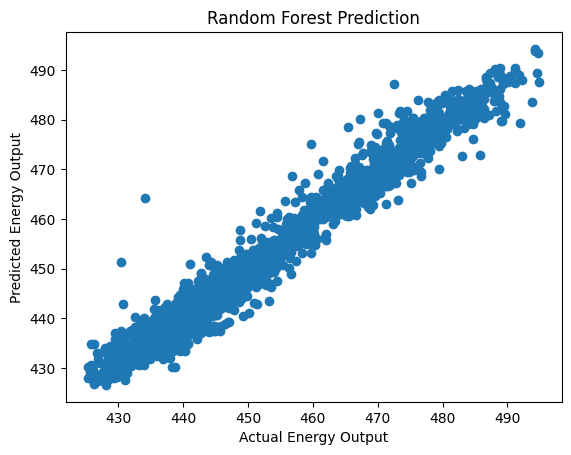

In [17]:
plt.scatter(y_test, modelRFRy_pred)
plt.xlabel("Actual Energy Output")
plt.ylabel("Predicted Energy Output")
plt.title("Random Forest Prediction")
plt.show()